# Time-Series ARIMA Forecast Analysis

Autoregressive Integrated Moving Average (ARIMA) models time-series data using past sequence observations (AR), trends differencing stages (I), and rolling average errors (MA) parameterized as $(p,d,q)$. This notebook generates a daily seasonal sequence (365 days), fits an ARIMA(2,1,1) model, forecasts a 30-day ahead window, and plots predicted values with confidence intervals in Matplotlib.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Generate synthetic seasonal daily sequence data (365 days)
np.random.seed(205)
n_days = 365
dates = pd.date_range(start='2025-01-01', periods=n_days, freq='D')

# Construct random walk + weekly seasonality + growth drift
time_index = np.arange(n_days)
drift = 0.08 * time_index
seasonality = np.sin(2 * np.pi * time_index / 7) * 4.0
noise = np.random.normal(0, 1.8, n_days)
signal = np.cumsum(noise) + drift + seasonality + 100.0

df_series = pd.DataFrame(signal, index=dates, columns=['Value'])
df_series.tail(10)



,Value
2025-12-22,132.565743
2025-12-23,132.391442
2025-12-24,134.978577
2025-12-25,138.451418
2025-12-26,137.939091
2025-12-27,135.259730
2025-12-28,131.614302
2025-12-29,130.189858
2025-12-30,127.754499
2025-12-31,133.256018


## Time-Series Split & Model Fitting

We reserve the last 30 days as test data and fit an ARIMA(2, 1, 1) model on the training data.



In [2]:
train_data = df_series.iloc[:-30]
test_data = df_series.iloc[-30:]

# Fit ARIMA(2,1,1) model
model = ARIMA(train_data['Value'], order=(2, 1, 1))
model_fit = model.fit()

print(model_fit.summary())



                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  335
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -712.805
Date:                Wed, 08 Jul 2026   AIC                           1433.611
Time:                        17:42:23   BIC                           1448.856
Sample:                    01-01-2025   HQIC                          1439.689
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0764      0.052     20.848      0.000       0.975       1.178
ar.L2         -0.7365      0.040    -18.415      0.000      -0.815      -0.658
ma.L1         -0.6347      0.056    -11.267      0.0

## Forecasting & Validation Performance

We forecast the next 30 days, calculate Mean Absolute Percentage Error (MAPE) against ground truths, and extract prediction confidence intervals.



In [3]:
# Forecast next 30 steps
forecast_result = model_fit.get_forecast(steps=30)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((test_data['Value'] - forecast_mean) / test_data['Value'])) * 100
print(f"ARIMA(2,1,1) Forecast MAPE: {mape:.2f}%")



ARIMA(2,1,1) Forecast MAPE: 3.55%


## ARIMA Predictions & Confidence Bounds Plot

Using Matplotlib, we chart the historical training sequence, the test actuals, and the forecasted values surrounded by transparent confidence bands.



<cell>:27: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



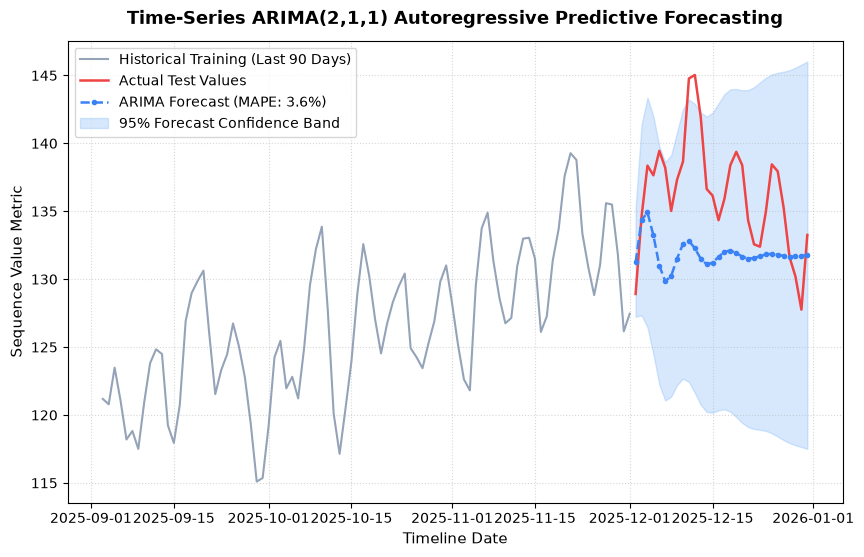

In [4]:
plt.figure(figsize=(10, 6))

# Plot historical train data
plt.plot(train_data.index[-90:], train_data['Value'][-90:], color='#94A3B8', label='Historical Training (Last 90 Days)', linewidth=1.5)

# Plot actual test data
plt.plot(test_data.index, test_data['Value'], color='#EF4444', label='Actual Test Values', linewidth=1.8)

# Plot forecast mean
plt.plot(test_data.index, forecast_mean, color='#3B82F6', linestyle='--', marker='o', markersize=3, label=f'ARIMA Forecast (MAPE: {mape:.1f}%)', linewidth=1.8)

# Plot confidence intervals
plt.fill_between(
    test_data.index, 
    forecast_ci.iloc[:, 0], 
    forecast_ci.iloc[:, 1], 
    color='#60A5FA', 
    alpha=0.25, 
    label='95% Forecast Confidence Band'
)

plt.title('Time-Series ARIMA(2,1,1) Autoregressive Predictive Forecasting', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Timeline Date', fontsize=11)
plt.ylabel('Sequence Value Metric', fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
